

1. **Feature Engineering**: 
   - Division and subtraction from `application_train.csv` (specifically dividing by `EXT_SOURCE_3`).
   - Label encoding for categorical variables.
   - Domain features: `credit_annuity_ratio`, `credit_goods_price_ratio`, `credit_downpayment`, `AGE_INT`.
2. **Base Models**: Diverse algorithms (LightGBM, XGBoost) using Stratified K-Fold CV (5 folds).
3. **Ensembling**: Blending the base model predictions.


In [1]:
import pandas as pd
import numpy as np
import gc
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
print("Loading data...")
# Load application data
app_train = pd.read_csv('Data/home_credit_data/application_train.csv')
app_test = pd.read_csv('Data/home_credit_data/application_test.csv')

# Combine for feature engineering
df = pd.concat([app_train, app_test]).reset_index(drop=True)
print(f"Combined df shape: {df.shape}")


Loading data...
Combined df shape: (356255, 122)


In [5]:
print("Applying Feature Engineering based on Top Solution Insights...")

# 1. Ratios and Differences
df['credit_annuity_ratio'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
df['credit_goods_price_ratio'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
df['credit_downpayment'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']
df['AGE_INT'] = (df['DAYS_BIRTH'] / -365).astype(int)

# 2. Division by EXT_SOURCE_3 (which gave a boost to CV)
for col in ['AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL']:
    df[f'{col}_div_EXT_SOURCE_3'] = df[col] / df['EXT_SOURCE_3']

# 3. Handle Anomaly
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# 4. Label encoding for all categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    # Fill NaN with a specific value 'NaN' to be able to encode
    df[col] = df[col].fillna('NaN')
    df[col] = le.fit_transform(df[col].astype(str))

print("Feature Engineering complete.")


Applying Feature Engineering based on Top Solution Insights...
Feature Engineering complete.


In [7]:
print("Preparing for modeling...")
train_df = df[df['TARGET'].notnull()].copy()
test_df = df[df['TARGET'].isnull()].copy()

features = [c for c in train_df.columns if c not in ['TARGET', 'SK_ID_CURR']]

y = train_df['TARGET']
X = train_df[features]
X_test = test_df[features]

# Stratified K-Fold setup
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_lgb = np.zeros(len(train_df))
sub_preds_lgb = np.zeros(len(test_df))

oof_preds_xgb = np.zeros(len(train_df))
sub_preds_xgb = np.zeros(len(test_df))

print("Starting training: LightGBM and XGBoost...")

for fold_, (trn_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f"--- Fold {fold_ + 1} ---")
    X_trn, y_trn = X.iloc[trn_idx], y.iloc[trn_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # --- LightGBM ---
    clf_lgb = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    clf_lgb.fit(
        X_trn, y_trn, 
        eval_set=[(X_val, y_val)], 
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    oof_preds_lgb[val_idx] = clf_lgb.predict_proba(X_val)[:, 1]
    sub_preds_lgb += clf_lgb.predict_proba(X_test)[:, 1] / folds.n_splits
    
    # --- XGBoost ---
    clf_xgb = xgb.XGBClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=11, # Approximate imbalance weight
        early_stopping_rounds=50,
        n_jobs=-1
    )
    clf_xgb.fit(
        X_trn, y_trn, 
        eval_set=[(X_val, y_val)], 
        verbose=False
    )
    oof_preds_xgb[val_idx] = clf_xgb.predict_proba(X_val)[:, 1]
    sub_preds_xgb += clf_xgb.predict_proba(X_test)[:, 1] / folds.n_splits

lgb_auc = roc_auc_score(y, oof_preds_lgb)
xgb_auc = roc_auc_score(y, oof_preds_xgb)

print(f"\n[Results]")
print(f"LightGBM OOF AUC: {lgb_auc:.5f}")
print(f"XGBoost OOF AUC:  {xgb_auc:.5f}")


Preparing for modeling...
Starting training: LightGBM and XGBoost...
--- Fold 1 ---
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13436
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 125
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
--- Fold 2 ---
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032227 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13493
[Light

Level 1 Ensembling (Equal Weighted Blend)...
Ensemble Blend OOF AUC: 0.76318
Submission file 'submission_first_solution_blend.csv' created.


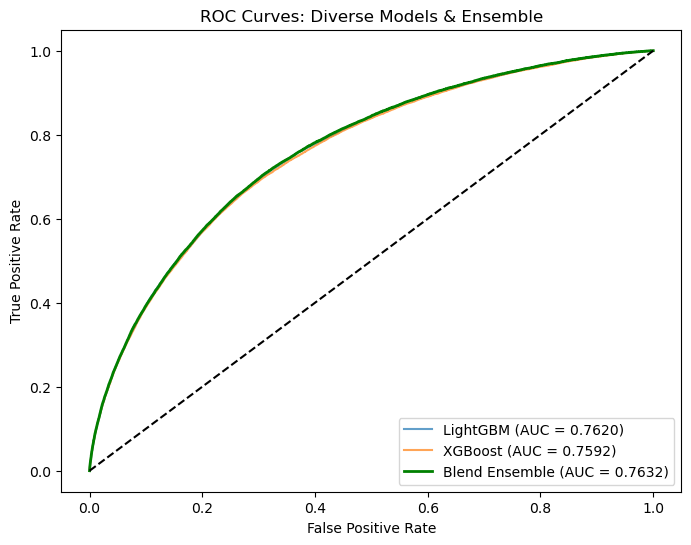

In [11]:
print("Level 1 Ensembling (Equal Weighted Blend)...")
# Since NN is missing in this simpler notebook, we blend the two diverse gradient boosters
oof_blend = 0.5 * oof_preds_lgb + 0.5 * oof_preds_xgb
sub_blend = 0.5 * sub_preds_lgb + 0.5 * sub_preds_xgb

blend_auc = roc_auc_score(y, oof_blend)
print(f"Ensemble Blend OOF AUC: {blend_auc:.5f}")

submission = pd.DataFrame({'SK_ID_CURR': test_df['SK_ID_CURR'], 'TARGET': sub_blend})
submission.to_csv('submission_first_solution_blend.csv', index=False)
print("Submission file 'submission_first_solution_blend.csv' created.")

# Plot ROC Curves to visualize diversity & blended improvement
from sklearn.metrics import roc_curve
plt.figure(figsize=(8, 6))

fpr_lgb, tpr_lgb, _ = roc_curve(y, oof_preds_lgb)
fpr_xgb, tpr_xgb, _ = roc_curve(y, oof_preds_xgb)
fpr_blend, tpr_blend, _ = roc_curve(y, oof_blend)

plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {lgb_auc:.4f})', alpha=0.7)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.4f})', alpha=0.7)
plt.plot(fpr_blend, tpr_blend, label=f'Blend Ensemble (AUC = {blend_auc:.4f})', color='green', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Diverse Models & Ensemble')
plt.legend(loc='lower right')
plt.show()
